## Question 2

In [5]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('spambase/spambase.data', header=None)

columns = [
    'word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d',
    'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet',
    'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will',
    'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free',
    'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit',
    'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money',
    'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650',
    'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857',
    'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology',
    'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct',
    'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project',
    'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference',
    'char_freq_;', 'char_freq_(', 'char_freq_[', 'char_freq_!',
    'char_freq_$', 'char_freq_#',
    'capital_run_length_average', 'capital_run_length_longest',
    'capital_run_length_total', 'spam'
]

df.columns = columns

X = df.drop(columns="spam")
y = df['spam']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=1
)

## Question 2.1

In [14]:
n_trees_list = [10, 50, 100, 500]

results = []

for t in n_trees_list:
    model = RandomForestClassifier(
        n_estimators=t,
        random_state=1
    )
    
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    y_train_prob = model.predict_proba(X_train)[:, 1]
    y_test_prob = model.predict_proba(X_test)[:, 1]
    
    results.append({
        "T": t,
        "train_accuracy": accuracy_score(y_train, y_train_pred),
        "test_accuracy": accuracy_score(y_test, y_test_pred),
        "train_f1": f1_score(y_train, y_train_pred),
        "test_f1": f1_score(y_test, y_test_pred),
        "train_auc": roc_auc_score(y_train, y_train_prob),
        "test_auc": roc_auc_score(y_test, y_test_prob)
    })

results_df = pd.DataFrame(results)
print(results_df)

     T  train_accuracy  test_accuracy  train_f1   test_f1  train_auc  test_auc
0   10        0.997101       0.947003  0.996329  0.930917   0.999948  0.982550
1   50        0.999710       0.965248  0.999633  0.954853   0.999999  0.988818
2  100        0.999710       0.966985  0.999633  0.957494   0.999999  0.989244
3  500        0.999710       0.966116  0.999633  0.956130   1.000000  0.988754


## Analysis

As T increases, training metrics increase every time. Looking at test metrics is where we get a little more insight. For all 3 metrics, as T increases so do the values until 100 to 500, where at 500 the metrics are all slightly lower than at T = 100. This shows that 500 is slightly too many and performs worse than just 100, although the difference is very small. 

## Question 2.2

## Analysis

Comparing the RandomForest metrics with the best T value (100) to the metrics obtained with our Decision Tree in problem 1, we see that the RandomForestClassifier performs better on every metric for the test set by around 0.05 for all values. This is a pretty significant increase, showing the advantage of using the Random Forest rather than just a single decision tree.

## Question 2.3

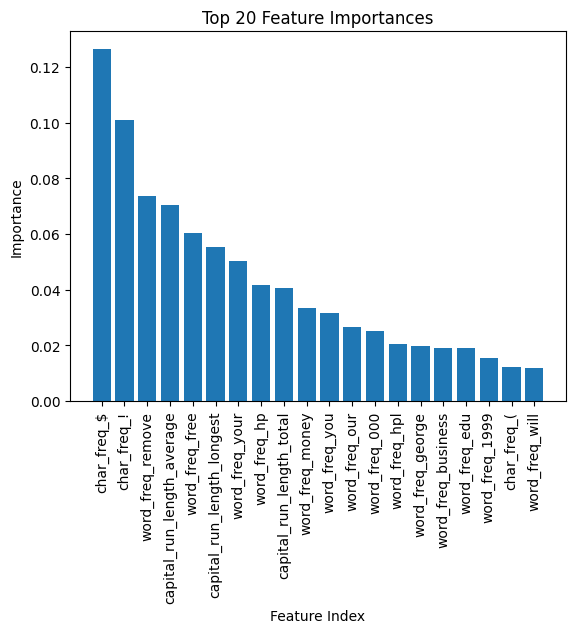

In [15]:
model = RandomForestClassifier(n_estimators=100, random_state=1)
model.fit(X_train, y_train)

importances = model.feature_importances_


indices = np.argsort(importances)[::-1]
feature_names = X.columns

top_k = 20

plt.figure()
plt.title("Top 20 Feature Importances")
plt.bar(range(top_k), importances[indices[:top_k]])
plt.xticks(range(top_k), feature_names[indices[:top_k]], rotation=90)
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.show()